In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, accuracy_score, recall_score, roc_auc_score, confusion_matrix, precision_score, precision_recall_curve

# Cấu hình hiển thị
plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

In [46]:
# Đọc dữ liệu
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

## Xử lí dữ liệu khuyết

In [47]:
# Xử lí kiểu dữ liệu cho cột Senior Citizen
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')

# Đồng bộ Yes / No giống những cột khác
df['SeniorCitizen'] = df['SeniorCitizen'].replace({1: 'Yes', 0: 'No'})

In [48]:
# Chuyển đổi kiểu dữ liệu của cột TotalCharges thành dạng số
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Điền khuyết TotalCharges bằng giá trị 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [49]:
# Kiểm tra lại tình trạng missing value và kiểu dữ liệu
print("Tên cột và kiểu dữ liệu:")
df.info()

Tên cột và kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

## Xử lí giá trị ngoại lai - Outlier

In [50]:
# Kiểm tra outlier
# Nhóm biến định lượng
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

def check_outliers_iqr(df, cols):
    print("=== KẾT QUẢ KIỂM TRA OUTLIER (PHƯƠNG PHÁP IQR) ===")

    for col in cols:
        # Tính toán Q1 (25%), Q3 (75%) và IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Xác định ngưỡng trên và dưới
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Lọc ra các dòng outlier
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        num_outliers = len(outliers)
        percentage = (num_outliers / len(df)) * 100

        print(f"\nbiến: {col}")
        print(f"- Khoảng chấp nhận: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"- Số lượng outlier: {num_outliers} dòng ({percentage:.2f}%)")

        # Nếu có outlier, in thử vài dòng để xem đó là dữ liệu gì
        if num_outliers > 0:
            print(f"- Ví dụ dữ liệu outlier (Top 3):")
            print(outliers[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head(3))

# Chạy hàm kiểm tra số liệu
check_outliers_iqr(df, numeric_cols)

=== KẾT QUẢ KIỂM TRA OUTLIER (PHƯƠNG PHÁP IQR) ===

biến: tenure
- Khoảng chấp nhận: [-60.00, 124.00]
- Số lượng outlier: 0 dòng (0.00%)

biến: MonthlyCharges
- Khoảng chấp nhận: [-46.02, 171.38]
- Số lượng outlier: 0 dòng (0.00%)

biến: TotalCharges
- Khoảng chấp nhận: [-4683.52, 8868.67]
- Số lượng outlier: 0 dòng (0.00%)


## Feature Engineering - Tạo đặc trưng mới

In [51]:
# Tạo biến Tổng số dịch vụ sử dụng (TotalServices)
# Suy nghĩ theo logic: Khách dùng càng nhiều dịch vụ trong hệ sinh thái thì càng khó rời bỏ
services_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
# Đếm số lượng dịch vụ khách hàng đang dùng (chỉ đếm nếu giá trị không phải 'No' hoặc 'No internet service')
df['TotalServices'] = df[services_cols].apply(lambda x: x.isin(['Yes', 'Fiber optic', 'DSL']).sum(), axis=1)

In [52]:
# Tạo biến giá cước trung bình trên mỗi dịch vụ AvgPricePerService
df['AvgPricePerService'] = df['MonthlyCharges'] / df['TotalServices'].replace(0, 1)

## Chuẩn bị dữ liệu train

In [53]:
# Xóa cột customerID - Biến mục tiêu
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

In [54]:
# Mã hóa biến Target (Churn): Yes -> 1, No -> 0
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [55]:
# Chọn các biến quan trọng để đưa vào mô hình
# Thay vì lấy tất cả, ta chỉ giữ lại những biến có sức ảnh hưởng lớn nhất
selected_features = [
    # Biến số (Numerical)
    'tenure', 'TotalCharges', 'MonthlyCharges',

    # Biến Feature Engineering
    'AvgPricePerService', 'TotalServices',

    # Biến phân loại (Categorical)
    'Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling',

    # Biến mục tiêu
    'Churn'
]
df_model = df[selected_features].copy()

print("Kích thước dữ liệu sau khi chọn biến:", df_model.shape)
print("Các cột được chọn:", df_model.columns.tolist())

Kích thước dữ liệu sau khi chọn biến: (7043, 10)
Các cột được chọn: ['tenure', 'TotalCharges', 'MonthlyCharges', 'AvgPricePerService', 'TotalServices', 'Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling', 'Churn']


In [56]:
# One-hot encoding - dành cho các biến phân loại
# Tự động biến đổi các cột phân loại thành số
df_model = pd.get_dummies(df_model, drop_first=True)

In [57]:
# Chia tập train - test
# Tách X, y
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Chia train/test (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [58]:
# Chuẩn hoá - dành cho các biến số
# Lọc ra các cột biến số cần scale
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgPricePerService', 'TotalServices']

scaler = StandardScaler()

# Tạo bản sao để không ảnh hưởng dữ liệu gốc
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale trên tập train và áp dụng transform lên tập test
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print('Đã chuẩn bị xong dữ liệu train')

Đã chuẩn bị xong dữ liệu train


## Tiến hành train lại model

- Sau khi hoàn tất quá trình lựa chọn biến, tiến hành tái huấn luyện các mô hình trên 9 biến quan trọng nhất.
- Mục tiêu của việc này là kiểm chứng xem việc loại bỏ các biến nhiễu có giúp mô hình duy trì được độ chính xác đồng thời giảm độ phức tạp tính toán và tăng khả năng giải thích
- Mô hình áp dụng: Tập trung vào 2 mô hình có hiệu năng tốt nhất ở giai đoạn trước
- Phương pháp: Giữ nguyên giai đoạn tiền xử lí, chỉ dùng bộ 9 biến quan trọng nhất

In [59]:
# Tạo DataFrame để lưu kết quả so sánh
model_comparison = pd.DataFrame(columns=['Model', 'Accuracy', 'Recall', 'Precision', 'ROC-AUC'])

def add_result(model_name, y_true, y_pred, y_prob=None):
    global model_comparison
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob) if y_prob is not None else 0

    new_row = pd.DataFrame({
        'Model': [model_name],
        'Accuracy': [acc],
        'Recall': [rec],
        'Precision': [prec],
        'ROC-AUC': [roc]
    })
    model_comparison = pd.concat([model_comparison, new_row], ignore_index=True)


--- Training Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



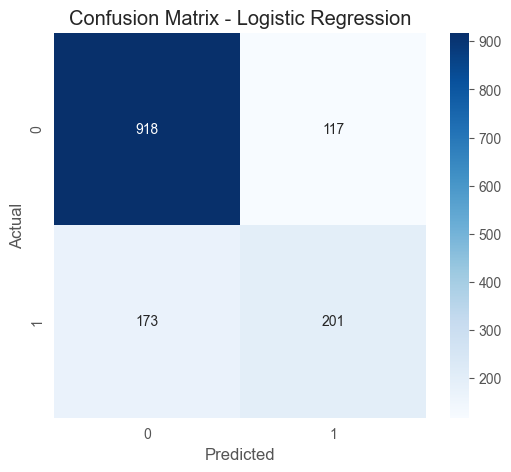

In [60]:
# Logistic Regression
print("\n--- Training Logistic Regression ---")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Lưu kết quả
add_result('Logistic Regression', y_test, y_pred_lr, y_prob_lr)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


--- Training Random Forest ---
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1035
           1       0.59      0.48      0.53       374

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409



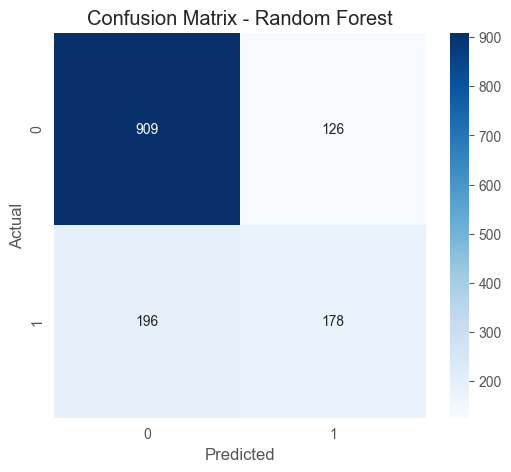

In [61]:
# Random Forest
print("\n--- Training Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Lưu kết quả
add_result('Random Forest', y_test, y_pred_rf, y_prob_rf)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


=== BẢNG XẾP HẠNG HIỆU NĂNG (Sắp xếp theo ROC-AUC) ===
                 Model  Accuracy    Recall  Precision   ROC-AUC
0  Logistic Regression  0.794180  0.537433   0.632075  0.835577
1        Random Forest  0.771469  0.475936   0.585526  0.807618


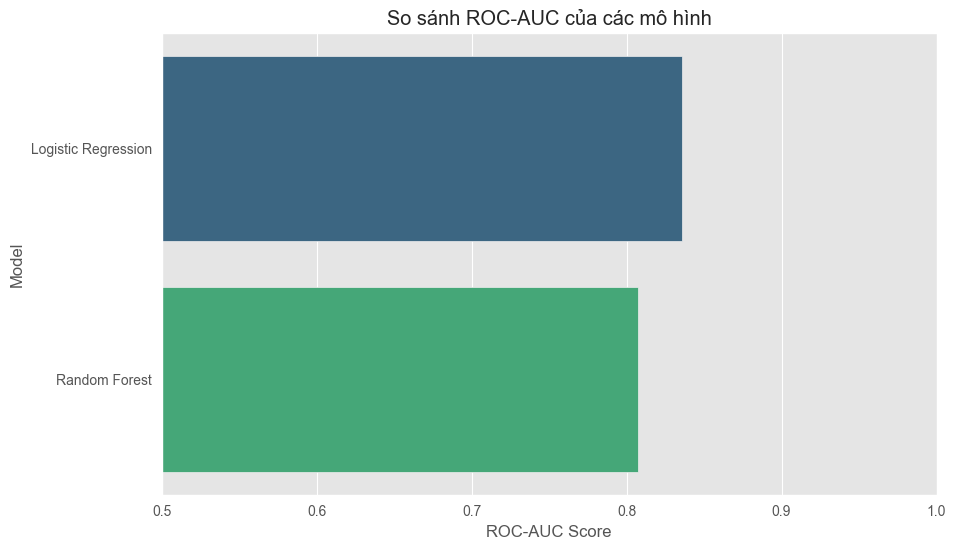

In [62]:
# Comparison Summary
print("\n=== BẢNG XẾP HẠNG HIỆU NĂNG (Sắp xếp theo ROC-AUC) ===")
# Sắp xếp theo ROC-AUC giảm dần để giống bảng mẫu
summary = model_comparison.sort_values(by='ROC-AUC', ascending=False)
print(summary)

# Vẽ biểu đồ so sánh ROC-AUC
plt.figure(figsize=(10, 6))
sns.barplot(x='ROC-AUC', y='Model', data=summary, palette='viridis')
plt.title('So sánh ROC-AUC của các mô hình')
plt.xlabel('ROC-AUC Score')
plt.ylabel('Model')
plt.xlim(0.5, 1.0)
plt.show()

- Logistic Regression: Vẫn duy trì phong độ ổn định với ROC-AUC đạt 0.8356. Việc giảm số lượng biến từ 24 xuống 9 hầu như không làm giảm hiệu năng dự báo, chứng tỏ 9 biến này thực sự nắm giữ thông tin cốt lõi
- Random Forest: Chỉ số ROC-AUC đạt 0.8076 và Recall chỉ dừng ở mức 0.4759
- **Vấn đề**: Cả hai mô hình cơ bản đều gặp khó khăn lớn ở chỉ số Recall (đều dưới 55%), có nghĩa là mô hình đang bỏ sót gần một nửa số lượng khách hàng rời bỏ thực tế. Nguyên nhân chính là do dữ liệu mất cân bằng, khiến mô hình có xu hướng dự đoán an toàn là "không rời bỏ"

## Cải thiện kết quả của mô hình (fine-tuning theo độ đo ROC-AUC)

- Để giải quyết vấn đề Recall thấp, nhóm đã áp dụng kỹ thuật GridSearchCV để tìm bộ tham số tối ưu theo hướng tối ưu độ đo ROC-AUC. Chiến lược này còn thử nghiệm kỹ thuật cân bằng trọng số lớp trực tiếp trong thuật toán để khắc phục hiện tượng mất cân bằng dữ liệu


--- Tuning Logistic Regression ---
Best Params: {'C': 10, 'class_weight': None, 'solver': 'liblinear'}
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.54      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



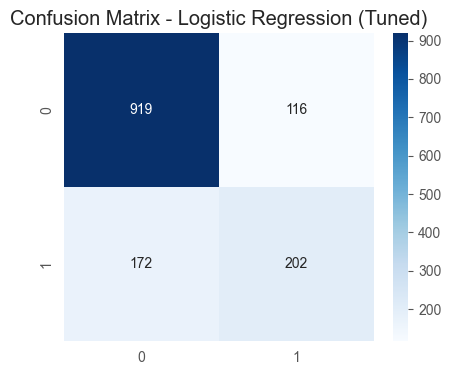

In [63]:
# Logistic Regression (Tuned)
print("\n--- Tuning Logistic Regression ---")
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000),
                       param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_
print("Best Params:", grid_lr.best_params_)

y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

add_result('Logistic Regression (Tuned)', y_test, y_pred_lr, y_prob_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (Tuned)')
plt.show()

In [ ]:
# Random Forest (Tuned)
print("\n--- Tuning Random Forest ---")
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid_rf, cv=3, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
print("Best Params:", grid_rf.best_params_)

y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

add_result('Random Forest (Tuned)', y_test, y_pred_rf, y_prob_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest (Tuned)')
plt.show()


--- Tuning Random Forest ---



=== BẢNG XẾP HẠNG HIỆU NĂNG SAU KHI FINE-TUNING (Sắp xếp theo ROC-AUC) ===
                         Model  Accuracy    Recall  Precision   ROC-AUC
3        Random Forest (Tuned)  0.763662  0.737968   0.540117  0.840775
2  Logistic Regression (Tuned)  0.795600  0.540107   0.635220  0.835784
0          Logistic Regression  0.794180  0.537433   0.632075  0.835577
1                Random Forest  0.771469  0.475936   0.585526  0.807618


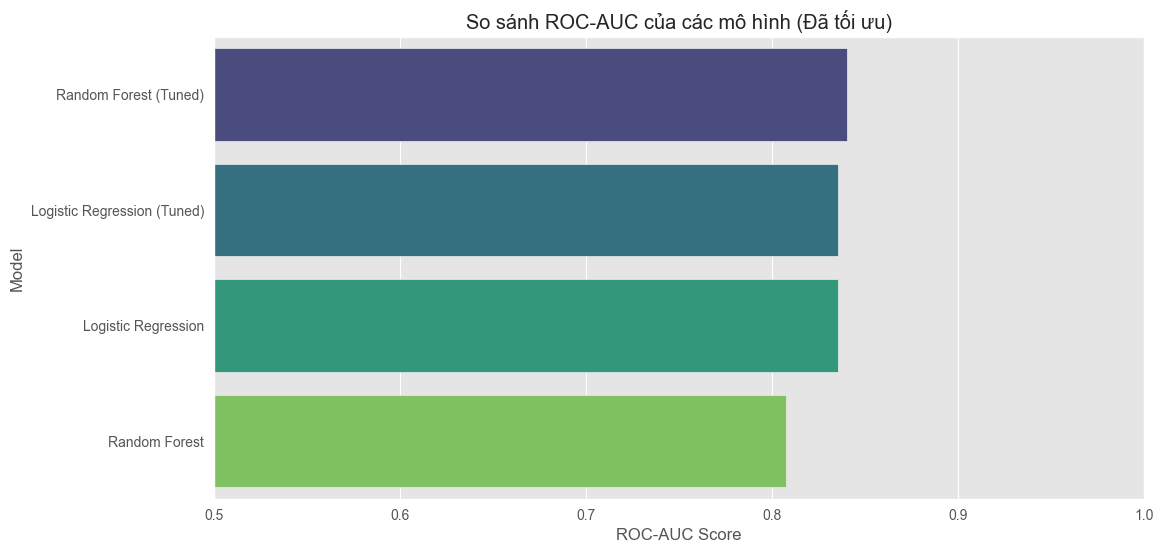

In [43]:
# Comparison Summary
print("\n=== BẢNG XẾP HẠNG HIỆU NĂNG SAU KHI FINE-TUNING (Sắp xếp theo ROC-AUC) ===")
summary = model_comparison.sort_values(by='ROC-AUC', ascending=False)
print(summary)

# Vẽ biểu đồ so sánh ROC-AUC
plt.figure(figsize=(12, 6))
sns.barplot(x='ROC-AUC', y='Model', data=summary, palette='viridis')
plt.title('So sánh ROC-AUC của các mô hình (Đã tối ưu)')
plt.xlabel('ROC-AUC Score')
plt.ylabel('Model')
plt.xlim(0.5, 1.0)
plt.show()

**Kết quả khả quan:**
- Sự cải thiện rõ rệt nhất nằm ở mô hình Random Forest sau khi tinh chỉnh:
Recall: Từ mức 0.4759 lên tới 0.738. Đây là một dấu hiệu rất tốt, cho thấy đã tìm ra được thêm 26% số khách hàng có nguy cơ rời bỏ mà mô hình cũ bỏ sót
- Mặc dù Accuracy giảm nhẹ và Precision giảm, nhưng chỉ số tổng quát ROC-AUC lại tăng lên mức cao nhất (0.8408)

## Threshold Moving - Tối ưu hoá ngưỡng

**Vấn đề thiết lập ngưỡng**
- Trong bài toán dự báo rời bỏ này, việc sử dụng ngưỡng mặc định 0.5 không phải lúc nào cũng tối ưu về mặt lợi ích kinh doanh. Vì khi dự đoán sai một khách hàng rời bỏ, sẽ mất đi doanh thu của khách hàng đó và phải tốn chi phí cao để tìm khách hàng thay thế (Rủi ro cao). Nhưng việc dự đoán nhầm một khách hàng trung thành chỉ tốn một khoản phí nhỏ để chăm sóc khách hàng (Rủi ro thấp hơn)

=== TỐI ƯU HÓA NGƯỠNG CHO RANDOM FOREST (TUNED) ===
Threshold  Recall     Precision  Accuracy  
---------------------------------------------
0.3        0.8877     0.4554     0.6884    
0.4        0.8289     0.5000     0.7346    
0.5        0.7380     0.5401     0.7637    
0.6        0.6578     0.5857     0.7857    


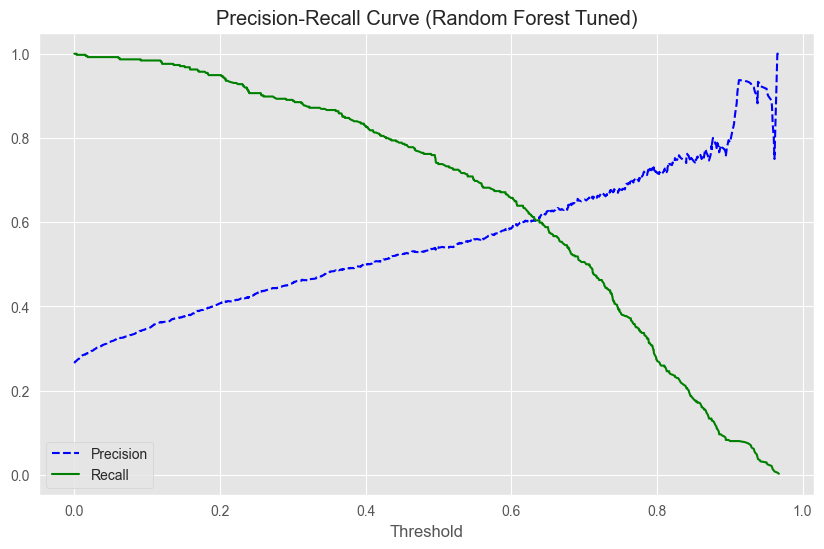

In [44]:
# Lấy mô hình Random Forest tốt nhất sau khi tune
best_rf_model = grid_rf.best_estimator_

# Lấy xác suất
y_prob_rf_tuned = best_rf_model.predict_proba(X_test_scaled)[:, 1]

print("=== TỐI ƯU HÓA NGƯỠNG CHO RANDOM FOREST (TUNED) ===")
thresholds = [0.3, 0.4, 0.5, 0.6]

print(f"{'Threshold':<10} {'Recall':<10} {'Precision':<10} {'Accuracy':<10}")
print("-" * 45)

for thresh in thresholds:
    y_pred_new = (y_prob_rf_tuned >= thresh).astype(int)

    rec = recall_score(y_test, y_pred_new)
    prec = precision_score(y_test, y_pred_new)
    acc = accuracy_score(y_test, y_pred_new)

    print(f"{thresh:<10} {rec:<10.4f} {prec:<10.4f} {acc:<10.4f}")

# Vẽ đường cong Precision-Recall
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_prob_rf_tuned)

plt.figure(figsize=(10, 6))
plt.plot(thresholds_pr, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds_pr, recalls[:-1], 'g-', label='Recall')
plt.xlabel('Threshold')
plt.title('Precision-Recall Curve (Random Forest Tuned)')
plt.legend()
plt.grid(True)
plt.show()

Dựa vào tính rủi ro của việc dự đoán nhầm khách hàng sẽ rời bỏ, nhóm quyết định chọn **ngưỡng 0.4 làm ngưỡng quyết định**:
- Tại ngưỡng 0.4, cứ 100 khách hàng rời bỏ mô hình sẽ dự đoán được khoảng 83 người trong đó (Recall = 0.8289), Mặc dù, tỷ lệ dự đoán đúng chỉ là 50% (Precision = 0.5,  cứ hai người bị cảnh báo thì có một người thực sự muốn rời bỏ) tuy nhiên việc chăm sóc nhầm một người để tránh nguy cơ một người rời bỏ là cái giá chấp nhận được trong bài toán dự đoán rời bỏ. Bởi vì chi phí chăm sóc khách hàng là thấp hơn nhiều so với mất đi doanh thu. Chỉ số accuracy = 0.7346 vẫn ở mức khá tốt